In [1]:
# ==========================================
# Laboratorio 7 - Deep Learning con PyTorch
# ==========================================

import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

# Reproducibilidad
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

PyTorch: 2.14.1
CUDA disponible: False


# 1. Redes multicapa con `nn.Module`

En esta sección se implementa un perceptrón multicapa (MLP) utilizando PyTorch para resolver el problema XOR. Este problema es un ejemplo clásico que demuestra la necesidad de utilizar capas ocultas y funciones de activación no lineales, ya que un perceptrón simple no puede separar correctamente las clases.

In [2]:
# Datos del problema XOR

X = torch.tensor([
    [0., 0.],
    [0., 1.],
    [1., 0.],
    [1., 1.]
])

y = torch.tensor([
    [0.],
    [1.],
    [1.],
    [0.]
])

print("Entradas:")
print(X)

print("\nEtiquetas:")
print(y)

Entradas:
tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]])

Etiquetas:
tensor([[0.],
        [1.],
        [1.],
        [0.]])


In [3]:
class MLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.hidden = nn.Linear(2, 4)
        self.relu = nn.ReLU()
        self.output = nn.Linear(4, 1)

    def forward(self, x):
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        return x


model = MLP()

print(model)

MLP(
  (hidden): Linear(in_features=2, out_features=4, bias=True)
  (relu): ReLU()
  (output): Linear(in_features=4, out_features=1, bias=True)
)


### Entrenamiento del modelo

Se entrena el MLP utilizando el conjunto de datos XOR para aprender la relación entre las entradas y sus etiquetas.

In [4]:
# Función de pérdida y optimizador
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

# Número de épocas
epochs = 5000

# Lista para guardar la pérdida
loss_history = []

# Entrenamiento
for epoch in range(epochs):

    # Forward
    outputs = model(X)
    loss = criterion(outputs, y)

    # Backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Guardar pérdida
    loss_history.append(loss.item())

    # Mostrar avance cada 500 épocas
    if (epoch + 1) % 500 == 0:
        print(f"Época {epoch+1}/{epochs} - Pérdida: {loss.item():.4f}")

Época 500/5000 - Pérdida: 0.3076
Época 1000/5000 - Pérdida: 0.0436
Época 1500/5000 - Pérdida: 0.0164
Época 2000/5000 - Pérdida: 0.0093
Época 2500/5000 - Pérdida: 0.0062
Época 3000/5000 - Pérdida: 0.0046
Época 3500/5000 - Pérdida: 0.0036
Época 4000/5000 - Pérdida: 0.0030
Época 4500/5000 - Pérdida: 0.0025
Época 5000/5000 - Pérdida: 0.0021


### Curva de pérdida

Se grafica la pérdida durante el entrenamiento para observar cómo aprende el modelo.

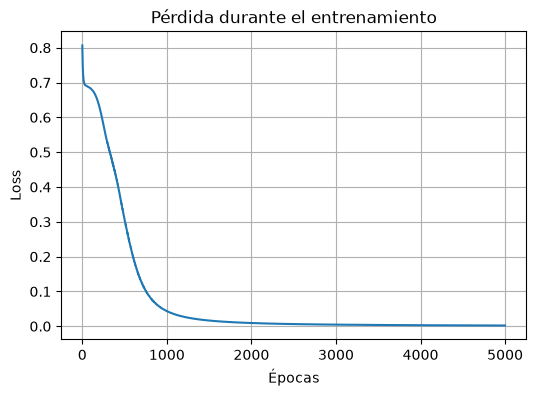

In [5]:
# Gráfica de la pérdida

plt.figure(figsize=(6,4))

plt.plot(loss_history)

plt.title("Pérdida durante el entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

### Evaluación del modelo

Se realizan las predicciones del modelo sobre el conjunto XOR y se calcula la exactitud obtenida.

In [6]:
# Evaluación
with torch.no_grad():

    logits = model(X)

    predictions = (torch.sigmoid(logits) >= 0.5).float()

    accuracy = (predictions == y).float().mean()

print("Predicciones:")
print(predictions)

print(f"\nExactitud: {accuracy.item()*100:.2f}%")

Predicciones:
tensor([[0.],
        [1.],
        [1.],
        [0.]])

Exactitud: 100.00%


### Análisis

La pérdida disminuyó de forma constante durante el entrenamiento hasta acercarse a cero. Al finalizar, el modelo clasificó correctamente los cuatro casos del problema XOR, alcanzando una exactitud del 100%.